# Verificación de secciones eficaces puntuales

Notebook autónomo que produce las **figuras y tablas** de la subsección
_Verificación de secciones eficaces puntuales_ del TFG.

Las cuatro verificaciones son independientes de la función de peso espectral `ITW`.

| Celda | Contenido |
|---|---|
| 0 | Imports |
| 1 | Constantes físicas |
| 2 | `PointCrossSections` (copia exacta del solver) |
| 3 | Materiales y composiciones |
| 4 | Lector ENDF/B-VII.1 puntual |
| 5 | Helpers XrayDB / Bragg |
| 6 | **V1** Elementos H,O,N  vs  XrayDB → figura + tabla |
| 7 | **V2** Elementos H,O,N  vs  ENDF/EPDL → figura + tabla |
| 8 | **V3** Agua y aire  vs  XrayDB → figura + tabla |
| 9 | **V4** Agua y aire  vs  ENDF/EPDL combinados → figura + tabla |
| 10 | Resumen final |

**Requisitos:** `numpy`, `pandas`, `matplotlib`, `xraydb`.

**Archivos ENDF** en `./endf_data/` :
- `photoat-001_H_000.endf`
- `photoat-007_N_000.endf`
- `photoat-008_O_000.endf`

In [19]:
# CELDA 0 -- Imports
import math, re
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams.update({'figure.dpi':110,'savefig.dpi':160,
                            'savefig.bbox':'tight','font.size':10,
                            'axes.grid':True,'grid.alpha':0.3})
import matplotlib.pyplot as plt
import xraydb
from pathlib import Path

# Carpeta donde se guardan las figuras producidas por este notebook
FIG_DIR = Path('figuras_puntual')
FIG_DIR.mkdir(exist_ok=True)

print(f'OK  NumPy {np.__version__}  |  figuras -> {FIG_DIR.resolve()}')


OK  NumPy 1.26.4  |  figuras -> /home/rober/figuras_puntual


## Celda 1 — Constantes físicas

In [20]:
# CELDA 1 -- Constantes fisicas (CGS)
import math, numpy as np

N_A         = 6.02214076e23
r_e_cm      = 2.8179403262e-13
sigma_T_cm2 = (8.0*math.pi/3.0) * r_e_cm**2
mec2_keV    = 511.0
DELTA_E_KEV = 1.0

print('OK  Constantes fisicas definidas')


OK  Constantes fisicas definidas


## Celda 2 — `PointCrossSections` (copia exacta del solver)

In [21]:
# CELDA 2 -- PointCrossSections  [Acuros Eq.(1); NJOY GAMINR Sec.9.1]

import numpy as np
import math

_Z_ELEM = {'H': 1, 'O': 8, 'N': 7}

# -- Tablas S(x,Z) ENDF/B-VII.1 File 27, MT=504
# S(x,Z): funcion de dispersion incoherente; S(x->inf,Z) = Z.
# Variable: x = 20.60744*q  [Ang^-1], NJOY GAMINR Eq.(382-383).

# H (Z=1)
_S_X_H_ENDF = np.array([
    0.000000e+00,1.000000e-07,1.000000e-06,1.000000e-05,1.000000e-04,1.000000e-03,
    5.000000e-03,1.000000e-02,1.500000e-02,2.000000e-02,2.500000e-02,3.000000e-02,
    3.750000e-02,4.000000e-02,4.750000e-02,5.000000e-02,5.875000e-02,6.625000e-02,
    7.000000e-02,7.875000e-02,8.000000e-02,8.625000e-02,9.000000e-02,9.750000e-02,
    1.000000e-01,1.062500e-01,1.156300e-01,1.250000e-01,1.359400e-01,1.453100e-01,
    1.500000e-01,1.609400e-01,1.703100e-01,1.750000e-01,1.875000e-01,2.000000e-01,
    2.125000e-01,2.218800e-01,2.289100e-01,2.359400e-01,2.429700e-01,2.500000e-01,
    2.625000e-01,2.718800e-01,2.789100e-01,2.906300e-01,2.929700e-01,3.000000e-01,
    3.179700e-01,3.250000e-01,3.330100e-01,3.497600e-01,3.625000e-01,3.677000e-01,
    3.892300e-01,4.000000e-01,4.250000e-01,4.437500e-01,4.500000e-01,4.718800e-01,
    5.000000e-01,5.250000e-01,5.625000e-01,6.000000e-01,6.500000e-01,7.000000e-01,
    7.500000e-01,8.000000e-01,8.750000e-01,9.000000e-01,1.000000e+00,1.125000e+00,
    1.250000e+00,1.437500e+00,1.500000e+00,1.750000e+00,2.000000e+00,2.500000e+00,
    3.000000e+00,3.500000e+00,4.000000e+00,5.000000e+00,6.000000e+00,7.000000e+00,
    8.000000e+00,1.000000e+01,1.500000e+01,2.000000e+01,5.000000e+01,8.000000e+01,
    1.000000e+02,1.000000e+03,1.000000e+06,1.000000e+09,
], dtype=float)
_S_VAL_H_ENDF = np.array([
    0.000000e+00,4.409700e-13,4.409700e-11,4.409700e-09,4.409700e-07,4.409700e-05,
    1.102425e-03,4.409700e-03,9.887600e-03,1.749400e-02,2.716600e-02,3.882600e-02,
    5.983670e-02,6.772900e-02,9.383850e-02,1.033100e-01,1.391020e-01,1.726290e-01,
    1.902300e-01,2.329580e-01,2.392320e-01,2.710060e-01,2.903800e-01,3.294640e-01,
    3.425600e-01,3.752390e-01,4.238310e-01,4.713000e-01,5.245410e-01,5.678810e-01,
    5.887300e-01,6.347230e-01,6.712280e-01,6.885000e-01,7.310720e-01,7.688400e-01,
    8.019520e-01,8.240260e-01,8.392010e-01,8.530840e-01,8.658780e-01,8.776800e-01,
    8.961610e-01,9.082310e-01,9.163850e-01,9.283980e-01,9.305910e-01,9.368600e-01,
    9.502770e-01,9.546510e-01,9.592280e-01,9.673380e-01,9.723280e-01,9.741820e-01,
    9.804080e-01,9.829800e-01,9.875650e-01,9.901100e-01,9.908580e-01,9.930070e-01,
    9.950200e-01,9.962740e-01,9.975580e-01,9.983700e-01,9.989660e-01,9.994100e-01,
    9.995910e-01,9.997600e-01,9.998670e-01,9.999000e-01,9.999500e-01,9.999710e-01,
    9.999900e-01,9.999980e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,
    1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,
    1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,
    1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,
], dtype=float)

# O (Z=8)
_S_X_O_ENDF = np.array([
    0.000000e+00,1.000000e-07,1.000000e-06,1.000000e-05,1.000000e-04,1.000000e-03,
    5.000000e-03,6.250000e-03,7.187500e-03,7.890600e-03,8.945300e-03,1.000000e-02,
    1.500000e-02,1.750000e-02,2.000000e-02,2.500000e-02,3.000000e-02,4.000000e-02,
    5.000000e-02,6.000000e-02,7.000000e-02,8.000000e-02,8.500000e-02,9.000000e-02,
    1.000000e-01,1.125000e-01,1.250000e-01,1.375000e-01,1.500000e-01,1.625000e-01,
    1.750000e-01,1.875000e-01,1.937500e-01,2.000000e-01,2.125000e-01,2.312500e-01,
    2.500000e-01,2.718800e-01,2.906300e-01,3.000000e-01,3.250000e-01,3.437500e-01,
    3.625000e-01,3.718800e-01,4.000000e-01,4.250000e-01,4.625000e-01,4.750000e-01,
    5.000000e-01,5.500000e-01,5.875000e-01,6.000000e-01,6.500000e-01,7.000000e-01,
    7.500000e-01,8.000000e-01,9.000000e-01,1.000000e+00,1.109400e+00,1.203100e+00,
    1.250000e+00,1.312500e+00,1.406300e+00,1.500000e+00,1.589800e+00,1.665000e+00,
    1.748800e+00,1.750000e+00,1.838500e+00,1.919300e+00,2.000000e+00,2.062500e+00,
    2.335900e+00,2.375000e+00,2.445300e+00,2.500000e+00,2.750000e+00,2.835900e+00,
    2.894500e+00,2.947300e+00,3.000000e+00,3.062500e+00,3.117200e+00,3.212900e+00,
    3.392300e+00,3.464100e+00,3.500000e+00,3.562500e+00,3.671900e+00,3.877000e+00,
    3.959000e+00,4.000000e+00,4.091800e+00,4.176000e+00,4.279000e+00,4.327100e+00,
    5.000000e+00,5.125000e+00,5.343800e+00,5.753900e+00,5.918000e+00,6.000000e+00,
    6.562500e+00,7.000000e+00,8.000000e+00,1.000000e+01,1.500000e+01,1.000000e+09,
], dtype=float)
_S_VAL_O_ENDF = np.array([
    0.000000e+00,1.100000e-12,1.100000e-10,1.100000e-08,1.100000e-06,1.100000e-04,
    2.750000e-03,4.296875e-03,5.682617e-03,6.848773e-03,8.802023e-03,1.100000e-02,
    2.530000e-02,3.441520e-02,4.480000e-02,6.980000e-02,1.001000e-01,1.761000e-01,
    2.710000e-01,3.841910e-01,5.137000e-01,6.568110e-01,7.328590e-01,8.118000e-01,
    9.770000e-01,1.194080e+00,1.419900e+00,1.651210e+00,1.885000e+00,2.118480e+00,
    2.349700e+00,2.576840e+00,2.688710e+00,2.799000e+00,3.014080e+00,3.322920e+00,
    3.613500e+00,3.927910e+00,4.176130e+00,4.293000e+00,4.580310e+00,4.774320e+00,
    4.951080e+00,5.033340e+00,5.257000e+00,5.429000e+00,5.647990e+00,5.711810e+00,
    5.828000e+00,6.020960e+00,6.139280e+00,6.175000e+00,6.301780e+00,6.411000e+00,
    6.507880e+00,6.596000e+00,6.755000e+00,6.901000e+00,7.047320e+00,7.161580e+00,
    7.215900e+00,7.283300e+00,7.377340e+00,7.462000e+00,7.533340e+00,7.586660e+00,
    7.639770e+00,7.640450e+00,7.689840e+00,7.729440e+00,7.764200e+00,7.787300e+00,
    7.867040e+00,7.875420e+00,7.890010e+00,7.899900e+00,7.934000e+00,7.943210e+00,
    7.948220e+00,7.952650e+00,7.957000e+00,7.960700e+00,7.963880e+00,7.969320e+00,
    7.976770e+00,7.979400e+00,7.980700e+00,7.982170e+00,7.984680e+00,7.989170e+00,
    7.990400e+00,7.991000e+00,7.991770e+00,7.992470e+00,7.993300e+00,7.993680e+00,
    7.997700e+00,7.997920e+00,7.998280e+00,7.998930e+00,7.999180e+00,7.999300e+00,
    7.999590e+00,7.999800e+00,8.000000e+00,8.000000e+00,8.000000e+00,8.000000e+00,
], dtype=float)

# N (Z=7)
_S_X_N_ENDF = np.array([
    0.000000e+00,1.000000e-07,1.000000e-06,1.000000e-05,1.000000e-04,1.000000e-03,
    5.000000e-03,6.718700e-03,7.890600e-03,9.296900e-03,1.000000e-02,1.125000e-02,
    1.500000e-02,2.000000e-02,2.500000e-02,3.000000e-02,4.000000e-02,5.000000e-02,
    5.875000e-02,6.000000e-02,7.000000e-02,8.000000e-02,9.000000e-02,1.000000e-01,
    1.109400e-01,1.125000e-01,1.203100e-01,1.250000e-01,1.375000e-01,1.500000e-01,
    1.625000e-01,1.750000e-01,1.875000e-01,1.937500e-01,2.000000e-01,2.125000e-01,
    2.312500e-01,2.500000e-01,2.718800e-01,2.750000e-01,2.906300e-01,3.000000e-01,
    3.250000e-01,3.437500e-01,3.718800e-01,4.000000e-01,4.437500e-01,4.812500e-01,
    5.000000e-01,5.250000e-01,5.625000e-01,5.750000e-01,6.000000e-01,6.500000e-01,
    7.000000e-01,8.000000e-01,8.750000e-01,9.000000e-01,9.750000e-01,1.000000e+00,
    1.085900e+00,1.144500e+00,1.214800e+00,1.250000e+00,1.312500e+00,1.406300e+00,
    1.500000e+00,1.617200e+00,1.712900e+00,1.750000e+00,1.784700e+00,1.838500e+00,
    1.919300e+00,2.000000e+00,2.062500e+00,2.308600e+00,2.375000e+00,2.377000e+00,
    2.459000e+00,2.500000e+00,2.750000e+00,2.835900e+00,2.894500e+00,2.947300e+00,
    3.000000e+00,3.062500e+00,3.117200e+00,3.212900e+00,3.392300e+00,3.464100e+00,
    3.500000e+00,3.562500e+00,3.671900e+00,4.000000e+00,4.125000e+00,4.234400e+00,
    4.425800e+00,5.000000e+00,5.250000e+00,5.718800e+00,6.000000e+00,6.625000e+00,
    6.875000e+00,7.000000e+00,7.250000e+00,7.718800e+00,7.906300e+00,8.000000e+00,
    8.125000e+00,8.359400e+00,8.654200e+00,8.900900e+00,9.529000e+00,1.000000e+01,
    1.045900e+01,1.088000e+01,1.139500e+01,1.205600e+01,1.247700e+01,1.373800e+01,
    1.500000e+01,1.718800e+01,1.906300e+01,2.000000e+01,2.187500e+01,2.363300e+01,
    2.692900e+01,2.981300e+01,5.000000e+01,5.750000e+01,8.000000e+01,1.000000e+02,
    1.270300e+02,1.557000e+02,1.855600e+02,2.162100e+02,2.652000e+02,3.326500e+02,
    3.945400e+02,4.702300e+02,5.673500e+02,6.755100e+02,8.174800e+02,1.000000e+03,
    1.171400e+03,1.365400e+03,1.706700e+03,2.048600e+03,2.521700e+03,3.357900e+03,
    4.681900e+03,6.333900e+03,1.036300e+04,1.589300e+04,3.032700e+04,7.267300e+04,
    2.695800e+05,1.000000e+06,5.623400e+06,5.424700e+07,1.000000e+09,
], dtype=float)
_S_VAL_N_ENDF = np.array([
    0.000000e+00,1.300000e-12,1.300000e-10,1.300000e-08,1.300000e-06,1.300000e-04,
    3.250000e-03,5.868321e-03,8.094004e-03,1.123621e-02,1.300000e-02,1.649010e-02,
    2.920000e-02,5.170000e-02,8.040000e-02,1.151000e-01,2.017000e-01,3.100000e-01,
    4.200330e-01,4.368180e-01,5.797000e-01,7.364600e-01,9.042000e-01,1.080000e+00,
    1.278750e+00,1.307440e+00,1.452170e+00,1.539700e+00,1.772470e+00,2.003000e+00,
    2.228330e+00,2.446800e+00,2.657050e+00,2.758520e+00,2.858000e+00,3.048640e+00,
    3.315380e+00,3.558600e+00,3.812940e+00,3.846890e+00,4.007360e+00,4.097000e+00,
    4.311800e+00,4.453020e+00,4.636790e+00,4.792000e+00,4.987420e+00,5.122470e+00,
    5.182000e+00,5.254070e+00,5.350560e+00,5.380580e+00,5.437000e+00,5.540240e+00,
    5.635000e+00,5.809000e+00,5.929580e+00,5.968000e+00,6.077840e+00,6.113000e+00,
    6.226560e+00,6.298480e+00,6.378060e+00,6.415700e+00,6.477240e+00,6.558950e+00,
    6.630000e+00,6.703240e+00,6.753430e+00,6.770310e+00,6.785630e+00,6.806880e+00,
    6.835130e+00,6.859900e+00,6.875510e+00,6.923390e+00,6.932290e+00,6.932540e+00,
    6.942620e+00,6.947000e+00,6.966450e+00,6.971560e+00,6.974260e+00,6.976650e+00,
    6.979000e+00,6.980790e+00,6.982330e+00,6.984950e+00,6.989520e+00,6.990710e+00,
    6.991300e+00,6.991920e+00,6.992990e+00,6.996000e+00,6.996430e+00,6.996790e+00,
    6.997410e+00,6.999100e+00,6.999290e+00,6.999620e+00,6.999800e+00,6.999860e+00,
    6.999890e+00,6.999900e+00,6.999930e+00,6.999970e+00,6.999990e+00,7.000000e+00,
    7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,
    7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,
    7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,
    7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,
    7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,
    7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,
    7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,
    7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,
    7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,
], dtype=float)

_SF_TABLES = {
    'H': (_S_X_H_ENDF, _S_VAL_H_ENDF),
    'O': (_S_X_O_ENDF, _S_VAL_O_ENDF),
    'N': (_S_X_N_ENDF, _S_VAL_N_ENDF),
}


def _compute_x_incoherent(E_keV: float, cos_theta: float) -> float:
    """Variable x = q*20.60744 para la dispersion incoherente. NJOY GAMINR Eq.(383)."""
    k = E_keV / mec2_keV
    dmu = 1.0 - cos_theta
    denom = 1.0 + k * dmu
    if denom <= 0.0:
        return 0.0
    num_sq = 1.0 + (k**2 + 2.0*k) * dmu / 2.0
    q = 2.0*k * math.sqrt(max(0.0, dmu/2.0)) * math.sqrt(max(0.0, num_sq)) / denom
    return 20.60744 * q


def _interp_scatter_function(x: float, elem: str) -> float:
    """Interpolacion log-log de S(x,Z) con tablas ENDF/B-VII.1 MT=504."""
    x_tbl, s_tbl = _SF_TABLES.get(elem, (None, None))
    if x_tbl is None or x <= 0.0:
        return 0.0
    if x >= x_tbl[-1]:
        return float(s_tbl[-1])
    eps = 1e-12
    mask = x_tbl > 0
    ln_x_tbl = np.log(x_tbl[mask])
    ln_s_tbl = np.log(np.clip(s_tbl[mask], eps, None))
    return float(math.exp(np.interp(math.log(x), ln_x_tbl, ln_s_tbl)))


class PointCrossSections:
    """Secciones eficaces puntuales: fotoelectrico Biggs-Lighthill + Compton KN*S(x,Z).

    API publica:
      photoelectric_mu_over_rho, compton_mu_over_rho, total_mu,
      macroscopic_total/compton/photoelectric,
      compton_incoherent_dsigma_dOmega_per_atom/per_mass/macroscopic,
      klein_nishina_dsigma_dOmega, compton_E_out, electron_density.

    Refs: Acuros Eq.(1); Vassiliev Sec.3.1; NJOY GAMINR Sec.9.1.
    """

    def __init__(self):
        self._pe_params = {
            'H': {
                'START':  [0.8,   4.0,   20.0,  100.0, 500.0],
                'FINISH': [4.0,   20.0,  100.0, 500.0, float('inf')],
                'A_1': [ 7.636E-02, 1.180E-03,+3.7783E-05, 1.034E-06, 4.599E-07],
                'A_2': [-9.406E-01,-8.236E-02,-9.2692E-03,-4.114E-04, 5.006E-04],
                'A_3': [ 6.144E+00, 2.886E+00,+1.3761E+00, 6.287E-01,-1.425E-02],
                'A_4': [ 1.425E+00, 5.534E+00,+1.5914E+01, 3.927E+01, 1.960E+02],
            },
            'N': {
                'START':  [0.8,   4.0,   20.0,  100.0, 500.0],
                'FINISH': [4.0,   20.0,  100.0, 500.0, float('inf')],
                'A_1': [-4.940E+00, 2.019E+00,+6.9367E-02, 1.872E-03, 8.122E-04],
                'A_2': [-8.442E+01,-1.249E+02,-1.7360E+01,-6.732E-01, 8.364E-01],
                'A_3': [ 4.620E+03, 4.609E+03,+2.8059E+03, 1.282E+03, 4.410E+02],
                'A_4': [-1.186E+03,-9.421E+02,+1.1254E+04, 5.700E+04, 2.358E+05],
            },
            'O': {
                'START':  [0.532, 4.0,   20.0,  100.0, 500.0],
                'FINISH': [4.0,   20.0,  100.0, 500.0, float('inf')],
                'A_1': [-7.181E+01, 2.745E+00,+1.1264E-01, 3.169E-03, 1.367E-03],
                'A_2': [ 4.748E+02,-1.747E+02,-2.8287E+01,-1.146E+00, 1.473E+00],
                'A_3': [ 5.542E+03, 7.159E+03,+4.6739E+03, 2.194E+03, 7.214E+02],
                'A_4': [-1.363E+03,-2.213E+03,+1.5005E+04, 9.131E+04, 4.048E+05],
            },
        }
        self._elements = ['H', 'O', 'N']
        self._Z_A    = {'H': 0.9921, 'O': 0.5, 'N': 4.998E-01}
        self._Z_ELEM = dict(_Z_ELEM)
        self._n_quad = 64
        self._mu_quad, self._w_quad = np.polynomial.legendre.leggauss(self._n_quad)

    # Klein-Nishina

    def _kn_dsigma_bare(self, E_in_keV: float, cos_theta: float) -> float:
        """dsigma_KN/dOmega [cm2/sr/e-] pura. Vassiliev Eq.(2.33)."""
        alpha = E_in_keV / mec2_keV
        if alpha <= 0:
            return 0.0
        k = 1.0 / (1.0 + alpha*(1.0 - cos_theta))
        if k <= 0:
            return 0.0
        return max(0.0, 0.5*r_e_cm**2 * k**2 * (k + 1.0/k - (1.0 - cos_theta**2)))

    def klein_nishina_dsigma_dOmega(self, E_in_keV: float, cos_theta: float) -> float:
        """dsigma_KN/dOmega [cm2/sr/e-]. Alias publico."""
        return self._kn_dsigma_bare(E_in_keV, cos_theta)

    # Seccion diferencial Compton

    def compton_incoherent_dsigma_dOmega_per_atom(self, E_in_keV, cos_theta, elem):
        """dsigma_C/dOmega [cm2/sr/atomo] = S(x,Z)*dsigma_KN. NJOY GAMINR Eq.(380)."""
        x_inc  = _compute_x_incoherent(E_in_keV, cos_theta)
        return max(0.0, _interp_scatter_function(x_inc, elem)
                        * self._kn_dsigma_bare(E_in_keV, cos_theta))

    def compton_incoherent_dsigma_dOmega_per_mass(self, E_in_keV, cos_theta, composition):
        """dsigma_C/dOmega [cm2/sr/g] para la mezcla. Vassiliev Sec.3.1."""
        dsig = self._kn_dsigma_bare(E_in_keV, cos_theta)
        if dsig <= 0.0:
            return 0.0
        x_inc = _compute_x_incoherent(E_in_keV, cos_theta)
        S_mix = 0.0
        for elem in self._elements:
            w_e = float(composition[elem].values[0]) / 100.0
            if w_e <= 0:
                continue
            S_mix += (w_e * self._Z_A[elem]
                      * _interp_scatter_function(x_inc, elem)
                      / float(self._Z_ELEM[elem]))
        return max(0.0, S_mix * N_A * dsig)

    def compton_incoherent_dsigma_dOmega_macroscopic(self, E_in_keV, cos_theta, rho, composition):
        """dSigma_C/dOmega [cm^-1/sr] = rho * dsigma_C/dOmega_masa."""
        return rho * self.compton_incoherent_dsigma_dOmega_per_mass(
            E_in_keV, cos_theta, composition)

    # Secciones integradas

    def photoelectric_mu_over_rho(self, E_keV: float, composition) -> float:
        """mu_PE/rho [cm2/g] por Biggs-Lighthill. Acuros Eq.(1)."""
        mu_pe = 0.0
        for elem in self._elements:
            w_e = float(composition[elem].values[0]) / 100.0
            if w_e <= 0:
                continue
            params = self._pe_params.get(elem)
            if params is None:
                continue
            for i in range(len(params['START'])):
                if params['START'][i] <= E_keV < params['FINISH'][i]:
                    A1, A2 = params['A_1'][i], params['A_2'][i]
                    A3, A4 = params['A_3'][i], params['A_4'][i]
                    mu_pe += w_e * (A1/E_keV + A2/E_keV**2
                                    + A3/E_keV**3 + A4/E_keV**4)
                    break
        return max(0.0, mu_pe)

    def compton_mu_over_rho(self, E_keV: float, composition) -> float:
        """mu_C/rho [cm2/g] = N_A*2*pi*integral(S*dsigma_KN dmu). NJOY GAMINR Eq.(380)."""
        if E_keV <= 0:
            return 0.0
        sigma_I = 0.0
        for mu_val, w_val in zip(self._mu_quad, self._w_quad):
            mu_f = float(mu_val)
            dsig_kn = self._kn_dsigma_bare(E_keV, mu_f)
            if dsig_kn <= 0.0:
                continue
            x_inc = _compute_x_incoherent(E_keV, mu_f)
            S_mix = 0.0
            for elem in self._elements:
                w_e = float(composition[elem].values[0]) / 100.0
                if w_e <= 0:
                    continue
                S_mix += (w_e * self._Z_A[elem]
                          * _interp_scatter_function(x_inc, elem)
                          / float(self._Z_ELEM[elem]))
            sigma_I += float(w_val) * dsig_kn * S_mix
        return max(0.0, sigma_I * 2.0*math.pi * N_A)

    def total_mu(self, E_keV: float, rho: float, composition) -> float:
        """Sigma_t [cm^-1] = rho*(mu_PE/rho + mu_C/rho). Acuros Eq.(1)."""
        return max(0.0, (self.photoelectric_mu_over_rho(E_keV, composition)
                         + self.compton_mu_over_rho(E_keV, composition)) * rho)

    def macroscopic_photoelectric(self, E_keV, rho, composition):
        """Sigma_PE [cm^-1]."""
        return rho * self.photoelectric_mu_over_rho(E_keV, composition)

    def macroscopic_compton(self, E_keV, rho, composition):
        """Sigma_C [cm^-1]."""
        return rho * self.compton_mu_over_rho(E_keV, composition)

    def macroscopic_total(self, E_keV, rho, composition):
        """Sigma_t [cm^-1]. Alias de total_mu."""
        return self.total_mu(E_keV, rho, composition)

    def compton_E_out(self, E_in_keV: float, cos_theta: float) -> float:
        """E_out [keV] = E / [1 + (E/mec2)*(1-cos)]. Vassiliev Eq.(2.34)."""
        denom = 1.0 + (E_in_keV / mec2_keV) * (1.0 - cos_theta)
        return E_in_keV / denom if denom > 0 else 0.0

    def electron_density(self, rho: float, composition) -> float:
        """n_e [e^-/cm3] = rho*N_A*sum_i w_i*(Z/A)_i. Vassiliev Sec.3.1."""
        e_per_g = sum(
            float(composition[el].values[0]) / 100.0 * self._Z_A[el]
            for el in self._elements
            if float(composition[el].values[0]) > 0 and el in self._Z_A
        )
        return rho * N_A * e_per_g


print('OK PointCrossSections definida')


OK PointCrossSections definida


## Celda 3 — Materiales

In [22]:
# CELDA 3 -- Materiales y composiciones
import pandas as pd

_MEDIA = pd.DataFrame({
    'Media_number': [0,    1     ],
    'Media_name':   ['Air','Water'],
    'Density':      [0.0012, 1.0  ],
    'H':  [ 0.0,     11.1898],
    'O':  [22.0,     88.8102],
    'N':  [78.0,      0.0   ],
})
MEDIA    = _MEDIA.set_index('Media_number')
COMP_H2O = MEDIA.loc[1:1]
COMP_AIR = MEDIA.loc[0:0]
RHO_H2O  = 1.0
RHO_AIR  = 0.0012

def comp_pure(elem: str):
    return pd.DataFrame({'H':[0.0],'O':[0.0],'N':[0.0], elem:[100.0]})

A_ATOMIC = {'H':1.00794,'N':14.0067,'O':15.9994}
Z_ATOMIC = {'H':1,'O':8,'N':7}

xs = PointCrossSections()
ne_h2o = xs.electron_density(RHO_H2O, COMP_H2O)
ne_air  = xs.electron_density(RHO_AIR, COMP_AIR)
print(f'n_e H2O = {ne_h2o:.4e} e-/cm3  |  n_e Aire = {ne_air:.4e} e-/cm3')
print('OK  Materiales definidos: COMP_H2O, COMP_AIR, comp_pure(elem)')


n_e H2O = 3.3427e+23 e-/cm3  |  n_e Aire = 3.6122e+20 e-/cm3
OK  Materiales definidos: COMP_H2O, COMP_AIR, comp_pure(elem)


## Celda 4 — Lector ENDF/B-VII.1 puntual

Parsea `MF=23 / MT=504` (Compton) y `MT=522` (fotoeléctrico). Los archivos ENDF deben estar en `./endf_data/`.

In [23]:
# CELDA 4 -- Lector ENDF/B-VII.1 puntual (MF=23 TAB1)
#
# Los tres ficheros ENDF deben estar en:
#   ./endf_data/materiales/photoat-001_H_000.endf
#   ./endf_data/materiales/photoat-007_N_000.endf
#   ./endf_data/materiales/photoat-008_O_000.endf
#
# MF=23: secciones eficaces foton-atomo
# MT=504  Compton incoherente [barn/atomo]
# MT=522  Fotoelectrico total [barn/atomo]

from pathlib import Path
import re
import numpy as np

ENDF_DIR = Path("./materiales")

ENDF_FILES = {
    "H": ENDF_DIR / "photoat-001_H_000.endf",
    "N": ENDF_DIR / "photoat-007_N_000.endf",
    "O": ENDF_DIR / "photoat-008_O_000.endf",
}

def _ef(s):
    """
    Convierte un campo ENDF de 11 caracteres a float.

    ENDF escribe, por ejemplo:
        1.23456+6  -> 1.23456e+6
        2.34567-3  -> 2.34567e-3
    """
    s = s.strip()
    if not s:
        return 0.0

    # Si ya viene en notación científica normal
    if "e" in s.lower():
        return float(s)

    # Inserta 'e' antes del signo del exponente ENDF
    return float(re.sub(r"([0-9.])([+-])", r"\1e\2", s))


def _endf_fields(line):
    """Devuelve los 6 campos numéricos ENDF de una línea."""
    return [_ef(line[i:i + 11]) for i in range(0, 66, 11)]


def parse_endf_tab1(path, mt_target):
    """
    Lee una tabla TAB1 de ENDF/B-VII.1 en MF=23 para un MT dado.

    Devuelve:
        E_keV : array
            Energías en keV.
        XS : array
            Sección eficaz en barn/átomo.

    Nota:
        Se asume interpolación log-log para su uso posterior, que es la
        apropiada para estas tablas foton-atomo en este contexto.
    """

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"No existe el fichero ENDF: {path}")

    block = []
    in_section = False

    with open(path, "r") as f:
        for ln in f:
            try:
                mf = int(ln[70:72])
                mt = int(ln[72:75])
            except Exception:
                continue

            if mf == 23 and mt == mt_target:
                in_section = True
                block.append(ln)

            elif in_section:
                # Salimos al terminar la sección MF=23, MT=mt_target
                break

    if len(block) < 3:
        return np.array([], dtype=float), np.array([], dtype=float)

    # En una sección ENDF:
    # block[0] suele ser HEAD
    # block[1] es el registro TAB1: C1 C2 L1 L2 NR NP
    try:
        tab1_header = _endf_fields(block[1])
        NR = int(tab1_header[4])
        NP = int(tab1_header[5])
    except Exception as exc:
        raise ValueError(f"No se pudo leer NR/NP en {path}, MT={mt_target}") from exc

    # Tras HEAD y TAB1 vienen las líneas de interpolación.
    # Cada línea contiene hasta 3 pares (NBT, INT), es decir, 6 campos.
    n_interp_lines = int(np.ceil((2 * NR) / 6))

    # Índice donde empiezan los pares (E, XS)
    data_start = 2 + n_interp_lines

    E = []
    XS = []

    for ln in block[data_start:]:
        vals = _endf_fields(ln)

        for k in range(0, 6, 2):
            x = vals[k]
            y = vals[k + 1]

            if x > 0:
                E.append(x)
                XS.append(y)

            if len(E) >= NP:
                break

        if len(E) >= NP:
            break

    if len(E) == 0:
        return np.array([], dtype=float), np.array([], dtype=float)

    E = np.asarray(E[:NP], dtype=float) / 1000.0  # eV -> keV
    XS = np.asarray(XS[:NP], dtype=float)

    # Ordenamos por energía
    idx = np.argsort(E)
    E = E[idx]
    XS = XS[idx]

    # Eliminamos posibles energías duplicadas, conservando la primera
    E_unique, unique_idx = np.unique(E, return_index=True)
    XS_unique = XS[unique_idx]

    return E_unique, XS_unique


_ecache = {}


def endf_xs_barn(E_keV, elem, mt):
    """
    Sección eficaz ENDF [barn/átomo] con interpolación log-log.

    Parámetros
    ----------
    E_keV : float o array
        Energía en keV.
    elem : str
        'H', 'N' u 'O'.
    mt : int
        MT de ENDF. Por ejemplo:
            504 -> Compton incoherente
            522 -> Fotoeléctrico total

    Devuelve
    --------
    float o array
        Sección eficaz en barn/átomo.
    """

    if elem not in ENDF_FILES:
        raise ValueError(f"Elemento no reconocido: {elem}. Usa 'H', 'N' u 'O'.")

    key = (elem, mt)

    if key not in _ecache:
        _ecache[key] = parse_endf_tab1(ENDF_FILES[elem], mt)

    Et, St = _ecache[key]

    scalar_input = np.isscalar(E_keV)
    Ea = np.atleast_1d(np.asarray(E_keV, dtype=float))

    out = np.full(Ea.shape, np.nan, dtype=float)

    # Para interpolar en log-log necesitamos valores estrictamente positivos
    mask = (Et > 0) & (St > 0)

    if np.count_nonzero(mask) < 2:
        return float(out[0]) if scalar_input else out

    Et_pos = Et[mask]
    St_pos = St[mask]

    inside = (Ea >= Et_pos[0]) & (Ea <= Et_pos[-1]) & (Ea > 0)

    out[inside] = np.exp(
        np.interp(
            np.log(Ea[inside]),
            np.log(Et_pos),
            np.log(St_pos)
        )
    )

    return float(out[0]) if scalar_input else out


def endf_xs_mass(E_keV, elem, mt):
    """
    Sección eficaz másica ENDF [cm2/g].

    Conversión:
        mu/rho = sigma[barn/atomo] * N_A / A * 1e-24
    """
    return endf_xs_barn(E_keV, elem, mt) * N_A / A_ATOMIC[elem] * 1e-24


# -------------------------------------------------------------------------
# Test rápido
# -------------------------------------------------------------------------

missing = [str(path) for path in ENDF_FILES.values() if not path.exists()]

if len(missing) == 0:
    print("OK  Archivos ENDF encontrados")

    for el in ["H", "O", "N"]:
        c = endf_xs_mass(50.0, el, 504)
        p = endf_xs_mass(50.0, el, 522)

        print(
            f"  {el} @ 50 keV: "
            f"C={c:.4e} cm2/g   "
            f"PE={p:.4e} cm2/g"
        )

else:
    print("AVISO: no se encontraron todos los archivos ENDF.")
    print("Faltan estos ficheros:")

    for path in missing:
        print(f"  - {path}")

    print()
    print("Coloca los tres ficheros .endf en:")
    print("  ./endf_data/materiales/")

OK  Archivos ENDF encontrados
  H @ 50 keV: C=3.3421e-01 cm2/g   PE=1.0587e-05 cm2/g
  O @ 50 keV: C=1.6103e-01 cm2/g   PE=3.0655e-02 cm2/g
  N @ 50 keV: C=1.6198e-01 cm2/g   PE=1.8643e-02 cm2/g


## Celda 5 — Helpers: XrayDB y mezclas por Bragg

In [24]:
# CELDA 5 -- Helpers: XrayDB y combinacion por composicion (Bragg)
import xraydb, numpy as np

def xr_C(E_keV, comp):
    return sum(float(comp[el].values[0])/100.0 * xraydb.mu_elam(el, E_keV*1000.0, kind='incoh')
               for el in ['H','O','N'] if float(comp[el].values[0]) > 0)

def xr_PE(E_keV, comp):
    return sum(float(comp[el].values[0])/100.0 * xraydb.mu_elam(el, E_keV*1000.0, kind='photo')
               for el in ['H','O','N'] if float(comp[el].values[0]) > 0)

def endf_C(E_keV, comp):
    return sum(float(comp[el].values[0])/100.0 * endf_xs_mass(E_keV, el, 504)
               for el in ['H','O','N'] if float(comp[el].values[0]) > 0)

def endf_PE(E_keV, comp):
    return sum(float(comp[el].values[0])/100.0 * endf_xs_mass(E_keV, el, 522)
               for el in ['H','O','N'] if float(comp[el].values[0]) > 0)

# Mallas de evaluacion  ── TODO entre 20 y 80 keV ───────────────────────────
E_CURVA = np.linspace(20.0, 80.0, 300)   # malla densa para curvas
E_TABLA = np.arange(20.0, 85.0, 5.0)     # malla fina (13 pts, cada 5 keV)
E_ELEM  = np.arange(20.0, 85.0, 10.0)    # malla elemento (7 pts, cada 10 keV)

ELEMS = ['H', 'O', 'N']
MATS  = [('H2O', COMP_H2O, RHO_H2O),
         ('Aire', COMP_AIR, RHO_AIR)]

print('OK  Helpers definidos  |  E_TABLA:', E_TABLA.tolist())


OK  Helpers definidos  |  E_TABLA: [20.0, 25.0, 30.0, 35.0, 40.0, 45.0, 50.0, 55.0, 60.0, 65.0, 70.0, 75.0, 80.0]


## Celda 6 — V1: elementos H, O y N frente a XrayDB

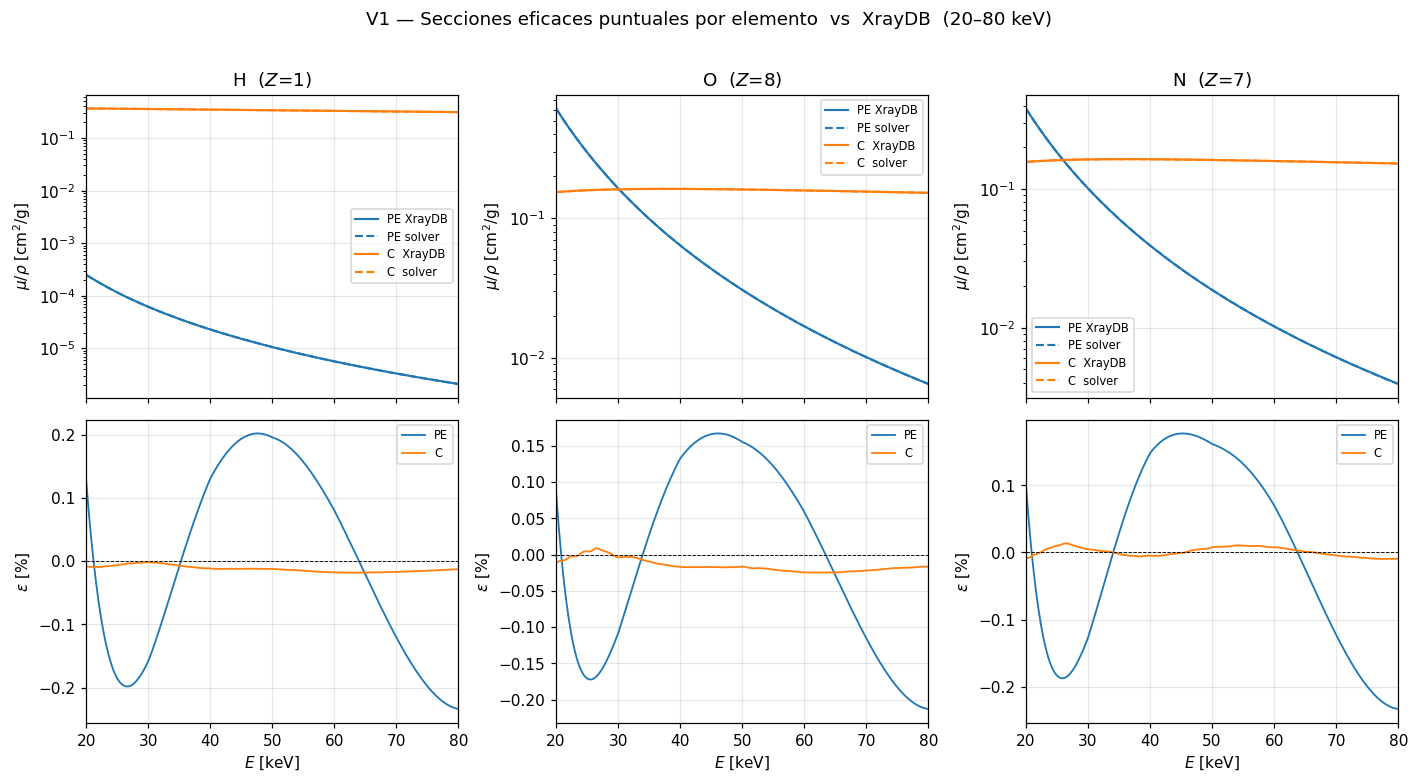

Fig guardada: V1_elem_xraydb.png

── Tabla V1 (cada 10 keV, 20-80 keV) ──

  H:
      E_keV      PE_ref      PE_sol    eps_PE_%       C_ref       C_sol     eps_C_%
 2.0000e+01  2.4987e-04  2.5019e-04  1.2670e-01  3.6256e-01  3.6253e-01 -8.6238e-03
 3.0000e+01  6.1672e-05  6.1574e-05 -1.5846e-01  3.5395e-01  3.5395e-01 -1.8915e-03
 4.0000e+01  2.2839e-05  2.2869e-05  1.3052e-01  3.4410e-01  3.4406e-01 -1.1695e-02
 5.0000e+01  1.0582e-05  1.0603e-05  1.9554e-01  3.3442e-01  3.3438e-01 -1.2384e-02
 6.0000e+01  5.6492e-06  5.6537e-06  8.0018e-02  3.2528e-01  3.2522e-01 -1.7843e-02
 7.0000e+01  3.3269e-06  3.3228e-06 -1.2080e-01  3.1670e-01  3.1664e-01 -1.7082e-02
 8.0000e+01  2.1051e-06  2.1002e-06 -2.3392e-01  3.0867e-01  3.0863e-01 -1.2808e-02

  O:
      E_keV      PE_ref      PE_sol    eps_PE_%       C_ref       C_sol     eps_C_%
 2.0000e+01  6.1240e-01  6.1293e-01  8.6424e-02  1.5402e-01  1.5400e-01 -1.1737e-02
 3.0000e+01  1.6414e-01  1.6396e-01 -1.0865e-01  1.6132e-01  1.6132e-01 -3

In [25]:
# CELDA 6 -- V1: elementos H, O y N frente a XrayDB
# Genera figura: figuras_puntual/V1_elem_xraydb.png

COLORS = {'C': 'C1', 'PE': 'C0'}

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex='col')
rows_V1 = []

for j, el in enumerate(ELEMS):
    comp = comp_pure(el)
    sol_PE = np.array([xs.photoelectric_mu_over_rho(E, comp) for E in E_CURVA])
    sol_C  = np.array([xs.compton_mu_over_rho(E, comp)       for E in E_CURVA])
    ref_PE = np.array([xraydb.mu_elam(el, E*1000.0, kind='photo') for E in E_CURVA])
    ref_C  = np.array([xraydb.mu_elam(el, E*1000.0, kind='incoh') for E in E_CURVA])

    ax = axes[0, j]
    ax.semilogy(E_CURVA, ref_PE, '-',  color=COLORS['PE'], label='PE XrayDB', lw=1.4)
    ax.semilogy(E_CURVA, sol_PE, '--', color=COLORS['PE'], label='PE solver',  lw=1.4)
    ax.semilogy(E_CURVA, ref_C,  '-',  color=COLORS['C'],  label='C  XrayDB',  lw=1.4)
    ax.semilogy(E_CURVA, sol_C,  '--', color=COLORS['C'],  label='C  solver',  lw=1.4)
    ax.set_title(f'{el}  ($Z$={Z_ATOMIC[el]})')
    ax.set_ylabel(r'$\mu/\rho$ [cm$^2$/g]')
    ax.set_xlim(20, 80)
    ax.legend(fontsize=7.5)

    ax = axes[1, j]
    ax.plot(E_CURVA, (sol_PE - ref_PE)/ref_PE*100, '-', color=COLORS['PE'], label='PE', lw=1.2)
    ax.plot(E_CURVA, (sol_C  - ref_C) /ref_C *100, '-', color=COLORS['C'],  label='C',  lw=1.2)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_xlabel('$E$ [keV]'); ax.set_ylabel('$\\varepsilon$ [%]')
    ax.set_xlim(20, 80)
    ax.legend(fontsize=7.5)

    for E in E_ELEM:
        r_pe = xraydb.mu_elam(el, E*1000.0, kind='photo')
        s_pe = xs.photoelectric_mu_over_rho(E, comp)
        r_c  = xraydb.mu_elam(el, E*1000.0, kind='incoh')
        s_c  = xs.compton_mu_over_rho(E, comp)
        rows_V1.append([el, E,
                        r_pe, s_pe, 100*(s_pe - r_pe)/r_pe,
                        r_c,  s_c,  100*(s_c  - r_c) /r_c])

plt.suptitle('V1 — Secciones eficaces puntuales por elemento  vs  XrayDB  (20–80 keV)', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'V1_elem_xraydb.png')
plt.show()
print('Fig guardada: V1_elem_xraydb.png')

df_V1 = pd.DataFrame(rows_V1,
    columns=['elem', 'E_keV', 'PE_ref', 'PE_sol', 'eps_PE_%', 'C_ref', 'C_sol', 'eps_C_%'])

print('\n── Tabla V1 (cada 10 keV, 20-80 keV) ──')
for el in ELEMS:
    sub = df_V1[df_V1.elem == el]
    print(f'\n  {el}:')
    print(sub[['E_keV', 'PE_ref', 'PE_sol', 'eps_PE_%', 'C_ref', 'C_sol', 'eps_C_%']]
          .to_string(index=False, float_format=lambda x: f'{x: .4e}'))

print('\n── |err|max ──')
for el in ELEMS:
    sub = df_V1[df_V1.elem == el]
    pe_max = sub['eps_PE_%'].abs().max()
    c_max  = sub['eps_C_%'].abs().max()
    print(f'  {el}:  PE = {pe_max:.2f}%   C = {c_max:.2f}%')


## Celda 7 — V2: elementos H, O y N frente a ENDF/B-VII.1 EPDL97

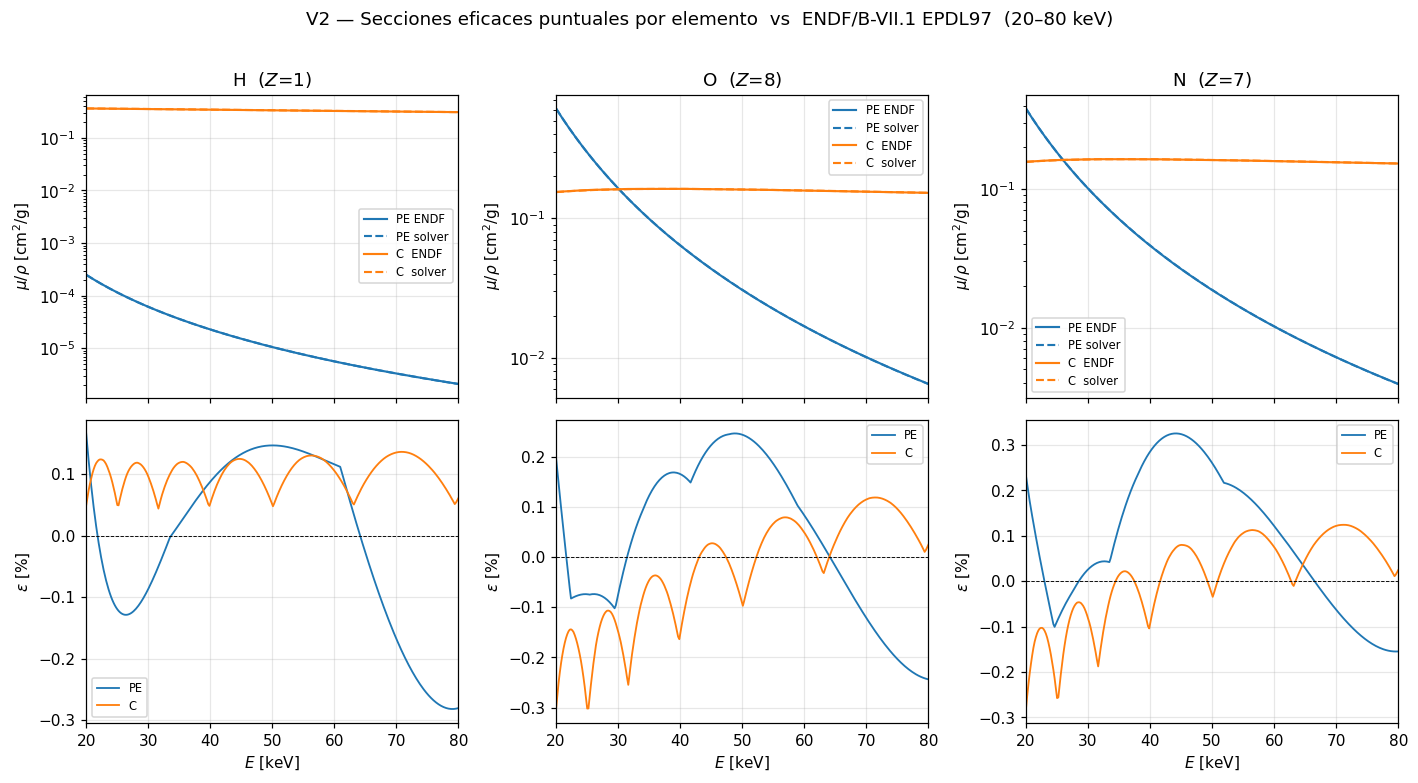

Fig guardada: V2_elem_endf.png

── Tabla V2 (cada 10 keV, 20-80 keV) ──

  H:
      E_keV      PE_ref      PE_sol    eps_PE_%       C_ref       C_sol     eps_C_%
 2.0000e+01  2.4978e-04  2.5019e-04  1.6620e-01  3.6235e-01  3.6253e-01  4.9369e-02
 3.0000e+01  6.1627e-05  6.1574e-05 -8.6877e-02  3.5361e-01  3.5395e-01  9.6348e-02
 4.0000e+01  2.2849e-05  2.2869e-05  8.7785e-02  3.4387e-01  3.4406e-01  5.2666e-02
 5.0000e+01  1.0587e-05  1.0603e-05  1.4671e-01  3.3421e-01  3.3438e-01  5.0456e-02
 6.0000e+01  5.6472e-06  5.6537e-06  1.1576e-01  3.2488e-01  3.2522e-01  1.0544e-01
 7.0000e+01  3.3284e-06  3.3228e-06 -1.6818e-01  3.1621e-01  3.1664e-01  1.3525e-01
 8.0000e+01  2.1061e-06  2.1002e-06 -2.8047e-01  3.0844e-01  3.0863e-01  6.1203e-02

  O:
      E_keV      PE_ref      PE_sol    eps_PE_%       C_ref       C_sol     eps_C_%
 2.0000e+01  6.1173e-01  6.1293e-01  1.9701e-01  1.5447e-01  1.5400e-01 -3.0259e-01
 3.0000e+01  1.6408e-01  1.6396e-01 -7.4483e-02  1.6156e-01  1.6132e-01 -1.4

In [26]:
# CELDA 7 -- V2: elementos H, O y N frente a ENDF/B-VII.1 EPDL97
# Genera figura: figuras_puntual/V2_elem_endf.png

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex='col')
rows_V2 = []

for j, el in enumerate(ELEMS):
    comp = comp_pure(el)
    sol_PE = np.array([xs.photoelectric_mu_over_rho(E, comp) for E in E_CURVA])
    sol_C  = np.array([xs.compton_mu_over_rho(E, comp)       for E in E_CURVA])
    ref_PE = endf_xs_mass(E_CURVA, el, 522)
    ref_C  = endf_xs_mass(E_CURVA, el, 504)

    ax = axes[0, j]
    ax.semilogy(E_CURVA, ref_PE, '-',  color=COLORS['PE'], label='PE ENDF',   lw=1.4)
    ax.semilogy(E_CURVA, sol_PE, '--', color=COLORS['PE'], label='PE solver',  lw=1.4)
    ax.semilogy(E_CURVA, ref_C,  '-',  color=COLORS['C'],  label='C  ENDF',    lw=1.4)
    ax.semilogy(E_CURVA, sol_C,  '--', color=COLORS['C'],  label='C  solver',  lw=1.4)
    ax.set_title(f'{el}  ($Z$={Z_ATOMIC[el]})')
    ax.set_ylabel(r'$\mu/\rho$ [cm$^2$/g]')
    ax.set_xlim(20, 80)
    ax.legend(fontsize=7.5)

    ax = axes[1, j]
    with np.errstate(invalid='ignore', divide='ignore'):
        ep = np.where(ref_PE > 0, (sol_PE - ref_PE)/ref_PE*100, np.nan)
        ec = np.where(ref_C  > 0, (sol_C  - ref_C) /ref_C *100, np.nan)
    ax.plot(E_CURVA, ep, '-', color=COLORS['PE'], label='PE', lw=1.2)
    ax.plot(E_CURVA, ec, '-', color=COLORS['C'],  label='C',  lw=1.2)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_xlabel('$E$ [keV]'); ax.set_ylabel('$\\varepsilon$ [%]')
    ax.set_xlim(20, 80)
    ax.legend(fontsize=7.5)

    for E in E_ELEM:
        r_pe = endf_xs_mass(E, el, 522)
        s_pe = xs.photoelectric_mu_over_rho(E, comp)
        r_c  = endf_xs_mass(E, el, 504)
        s_c  = xs.compton_mu_over_rho(E, comp)
        rows_V2.append([el, E,
                        r_pe, s_pe, 100*(s_pe - r_pe)/r_pe if r_pe > 0 else np.nan,
                        r_c,  s_c,  100*(s_c  - r_c) /r_c])

plt.suptitle('V2 — Secciones eficaces puntuales por elemento  vs  ENDF/B-VII.1 EPDL97  (20–80 keV)', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'V2_elem_endf.png')
plt.show()
print('Fig guardada: V2_elem_endf.png')

df_V2 = pd.DataFrame(rows_V2,
    columns=['elem', 'E_keV', 'PE_ref', 'PE_sol', 'eps_PE_%', 'C_ref', 'C_sol', 'eps_C_%'])

print('\n── Tabla V2 (cada 10 keV, 20-80 keV) ──')
for el in ELEMS:
    sub = df_V2[df_V2.elem == el]
    print(f'\n  {el}:')
    print(sub[['E_keV', 'PE_ref', 'PE_sol', 'eps_PE_%', 'C_ref', 'C_sol', 'eps_C_%']]
          .to_string(index=False, float_format=lambda x: f'{x: .4e}'))

print('\n── |err|max ──')
for el in ELEMS:
    sub = df_V2[df_V2.elem == el]
    pe_max = sub['eps_PE_%'].abs().max()
    c_max  = sub['eps_C_%'].abs().max()
    print(f'  {el}:  PE = {pe_max:.2f}%   C = {c_max:.2f}%')


## Celda 8 — V3: agua y aire frente a XrayDB

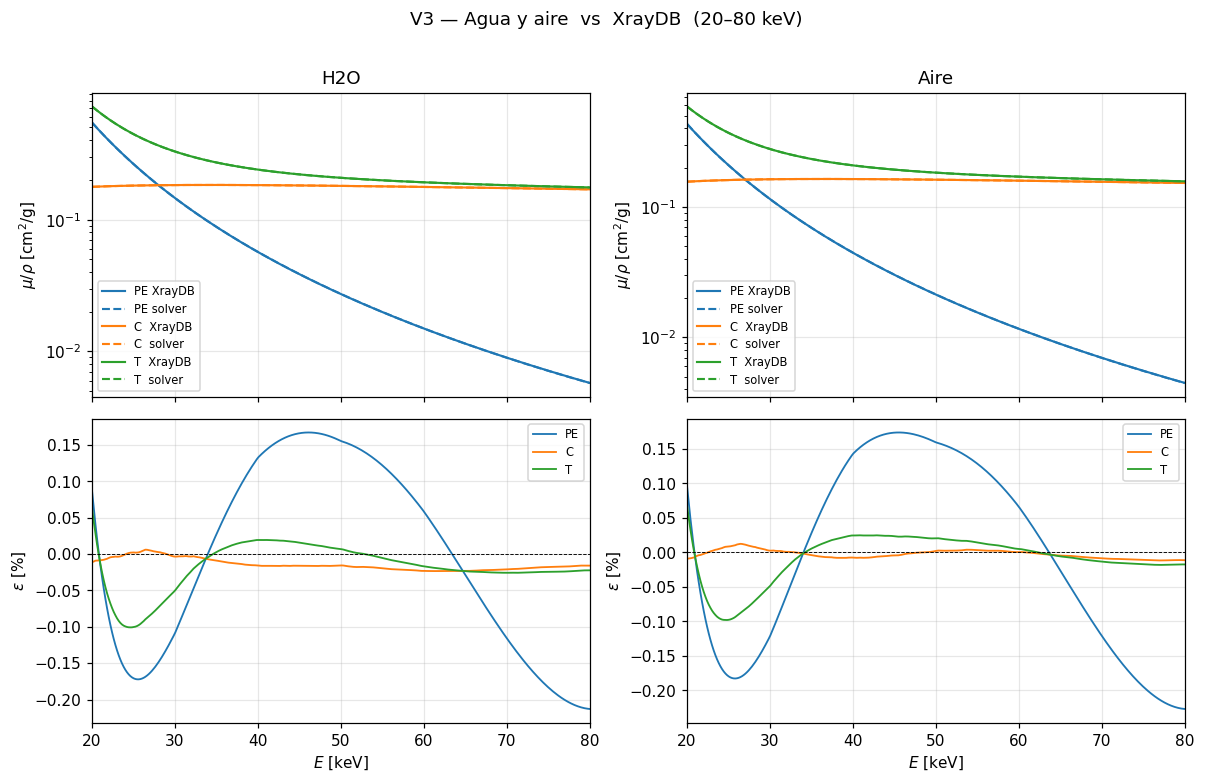

Fig guardada: V3_mats_xraydb.png

── Tabla V3 (cada 5 keV, 20-80 keV) ──

  H2O:
      E_keV      PE_ref      PE_sol    eps_PE_%       C_ref       C_sol     eps_C_%       T_ref       T_sol     eps_T_%
 2.0000e+01  5.4391e-01  5.4438e-01  8.6426e-02  1.7736e-01  1.7734e-01 -1.1025e-02  7.2126e-01  7.2171e-01  6.2463e-02
 2.5000e+01  2.6404e-01  2.6359e-01 -1.7068e-01  1.8119e-01  1.8119e-01  2.2607e-03  4.4523e-01  4.4478e-01 -1.0030e-01
 3.0000e+01  1.4578e-01  1.4562e-01 -1.0865e-01  1.8288e-01  1.8287e-01 -3.4491e-03  3.2865e-01  3.2849e-01 -5.0113e-02
 3.5000e+01  8.8025e-02  8.8049e-02  2.7321e-02  1.8324e-01  1.8322e-01 -8.9641e-03  2.7126e-01  2.7127e-01  2.8105e-03
 4.0000e+01  5.6790e-02  5.6866e-02  1.3245e-01  1.8274e-01  1.8272e-01 -1.5674e-02  2.3954e-01  2.3958e-01  1.9445e-02
 4.5000e+01  3.8556e-02  3.8620e-02  1.6607e-01  1.8170e-01  1.8167e-01 -1.6026e-02  2.2026e-01  2.2030e-01  1.5850e-02
 5.0000e+01  2.7250e-02  2.7293e-02  1.5537e-01  1.8033e-01  1.8030e-01 -1.5604

In [27]:
# CELDA 8 -- V3: agua y aire frente a XrayDB
# Genera figura: figuras_puntual/V3_mats_xraydb.png

COLORES_MAT = {'C': 'C1', 'PE': 'C0', 'T': 'C2'}

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex='col')
rows_V3 = []

for j, (name, comp, rho) in enumerate(MATS):
    sol_PE = np.array([xs.photoelectric_mu_over_rho(E, comp) for E in E_CURVA])
    sol_C  = np.array([xs.compton_mu_over_rho(E, comp)       for E in E_CURVA])
    ref_PE = np.array([xr_PE(E, comp) for E in E_CURVA])
    ref_C  = np.array([xr_C(E, comp)  for E in E_CURVA])
    sol_T  = sol_PE + sol_C
    ref_T  = ref_PE + ref_C

    ax = axes[0, j]
    ax.semilogy(E_CURVA, ref_PE, '-',  color=COLORES_MAT['PE'], label='PE XrayDB', lw=1.4)
    ax.semilogy(E_CURVA, sol_PE, '--', color=COLORES_MAT['PE'], label='PE solver',  lw=1.4)
    ax.semilogy(E_CURVA, ref_C,  '-',  color=COLORES_MAT['C'],  label='C  XrayDB',  lw=1.4)
    ax.semilogy(E_CURVA, sol_C,  '--', color=COLORES_MAT['C'],  label='C  solver',  lw=1.4)
    ax.semilogy(E_CURVA, ref_T,  '-',  color=COLORES_MAT['T'],  label='T  XrayDB',  lw=1.4)
    ax.semilogy(E_CURVA, sol_T,  '--', color=COLORES_MAT['T'],  label='T  solver',  lw=1.4)
    ax.set_title(name)
    ax.set_ylabel(r'$\mu/\rho$ [cm$^2$/g]')
    ax.set_xlim(20, 80)
    ax.legend(fontsize=7.5)

    ax = axes[1, j]
    ax.plot(E_CURVA, (sol_PE - ref_PE)/ref_PE*100, '-', color=COLORES_MAT['PE'], label='PE', lw=1.2)
    ax.plot(E_CURVA, (sol_C  - ref_C) /ref_C *100, '-', color=COLORES_MAT['C'],  label='C',  lw=1.2)
    ax.plot(E_CURVA, (sol_T  - ref_T) /ref_T *100, '-', color=COLORES_MAT['T'],  label='T',  lw=1.2)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_xlabel('$E$ [keV]'); ax.set_ylabel('$\\varepsilon$ [%]')
    ax.set_xlim(20, 80)
    ax.legend(fontsize=7.5)

    for E in E_TABLA:
        r_pe = xr_PE(E, comp); s_pe = xs.photoelectric_mu_over_rho(E, comp)
        r_c  = xr_C(E, comp);  s_c  = xs.compton_mu_over_rho(E, comp)
        r_t  = r_pe + r_c;     s_t  = s_pe + s_c
        rows_V3.append([name, E,
                        r_pe, s_pe, 100*(s_pe - r_pe)/r_pe,
                        r_c,  s_c,  100*(s_c  - r_c) /r_c,
                        r_t,  s_t,  100*(s_t  - r_t) /r_t])

plt.suptitle('V3 — Agua y aire  vs  XrayDB  (20–80 keV)', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'V3_mats_xraydb.png')
plt.show()
print('Fig guardada: V3_mats_xraydb.png')

df_V3 = pd.DataFrame(rows_V3,
    columns=['mat', 'E_keV',
             'PE_ref', 'PE_sol', 'eps_PE_%',
             'C_ref',  'C_sol',  'eps_C_%',
             'T_ref',  'T_sol',  'eps_T_%'])

print('\n── Tabla V3 (cada 5 keV, 20-80 keV) ──')
for name, _, _ in MATS:
    sub = df_V3[df_V3.mat == name]
    print(f'\n  {name}:')
    print(sub[['E_keV', 'PE_ref', 'PE_sol', 'eps_PE_%', 'C_ref', 'C_sol', 'eps_C_%', 'T_ref', 'T_sol', 'eps_T_%']]
          .to_string(index=False, float_format=lambda x: f'{x: .4e}'))

print('\n── |err|max ──')
for name, _, _ in MATS:
    sub = df_V3[df_V3.mat == name]
    pe_max = sub['eps_PE_%'].abs().max()
    c_max  = sub['eps_C_%'].abs().max()
    t_max  = sub['eps_T_%'].abs().max()
    print(f'  {name}: PE={pe_max:.2f}%  C={c_max:.2f}%  T={t_max:.2f}%')


## Celda 9 — V4: agua y aire frente a ENDF/B-VII.1 EPDL97 combinados

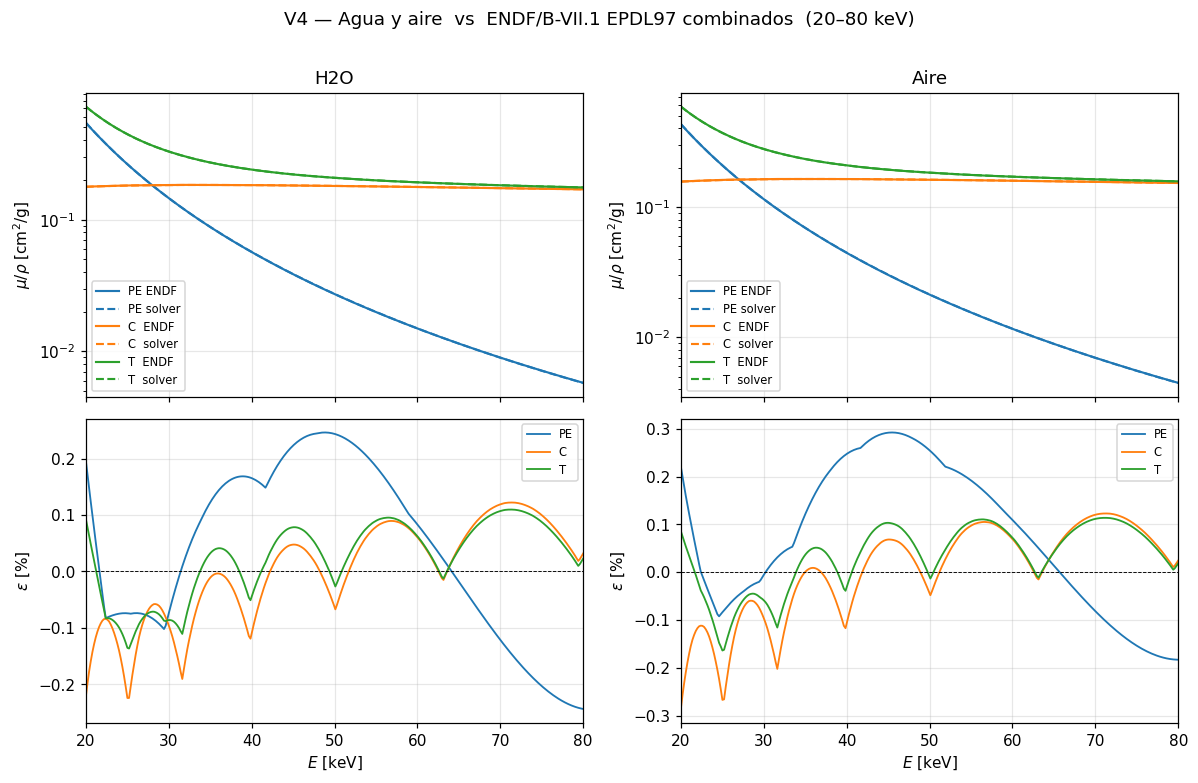

Fig guardada: V4_mats_endf.png

── Tabla V4 (cada 5 keV, 20-80 keV) ──

  H2O:
      E_keV      PE_ref      PE_sol    eps_PE_%       C_ref       C_sol     eps_C_%       T_ref       T_sol     eps_T_%
 2.0000e+01  5.4330e-01  5.4438e-01  1.9701e-01  1.7773e-01  1.7734e-01 -2.2230e-01  7.2104e-01  7.2171e-01  9.3651e-02
 2.5000e+01  2.6379e-01  2.6359e-01 -7.4006e-02  1.8159e-01  1.8119e-01 -2.2233e-01  4.4538e-01  4.4478e-01 -1.3448e-01
 3.0000e+01  1.4573e-01  1.4562e-01 -7.4483e-02  1.8305e-01  1.8287e-01 -9.5281e-02  3.2877e-01  3.2849e-01 -8.6063e-02
 3.5000e+01  8.7942e-02  8.8049e-02  1.2217e-01  1.8324e-01  1.8322e-01 -1.1168e-02  2.7118e-01  2.7127e-01  3.2073e-02
 4.0000e+01  5.6772e-02  5.6866e-02  1.6534e-01  1.8292e-01  1.8272e-01 -1.1010e-01  2.3969e-01  2.3958e-01 -4.4865e-02
 4.5000e+01  3.8534e-02  3.8620e-02  2.2292e-01  1.8159e-01  1.8167e-01  4.7589e-02  2.2012e-01  2.2030e-01  7.8283e-02
 5.0000e+01  2.7226e-02  2.7293e-02  2.4367e-01  1.8041e-01  1.8030e-01 -6.2754e-

In [28]:
# CELDA 9 -- V4: agua y aire frente a ENDF/B-VII.1 EPDL97 combinados por composicion
# Genera figura: figuras_puntual/V4_mats_endf.png

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex='col')
rows_V4 = []

for j, (name, comp, rho) in enumerate(MATS):
    sol_PE = np.array([xs.photoelectric_mu_over_rho(E, comp) for E in E_CURVA])
    sol_C  = np.array([xs.compton_mu_over_rho(E, comp)       for E in E_CURVA])
    ref_PE = np.array([endf_PE(E, comp) for E in E_CURVA])
    ref_C  = np.array([endf_C(E, comp)  for E in E_CURVA])
    sol_T  = sol_PE + sol_C
    ref_T  = ref_PE + ref_C

    ax = axes[0, j]
    ax.semilogy(E_CURVA, ref_PE, '-',  color=COLORES_MAT['PE'], label='PE ENDF',  lw=1.4)
    ax.semilogy(E_CURVA, sol_PE, '--', color=COLORES_MAT['PE'], label='PE solver', lw=1.4)
    ax.semilogy(E_CURVA, ref_C,  '-',  color=COLORES_MAT['C'],  label='C  ENDF',  lw=1.4)
    ax.semilogy(E_CURVA, sol_C,  '--', color=COLORES_MAT['C'],  label='C  solver', lw=1.4)
    ax.semilogy(E_CURVA, ref_T,  '-',  color=COLORES_MAT['T'],  label='T  ENDF',  lw=1.4)
    ax.semilogy(E_CURVA, sol_T,  '--', color=COLORES_MAT['T'],  label='T  solver', lw=1.4)
    ax.set_title(name)
    ax.set_ylabel(r'$\mu/\rho$ [cm$^2$/g]')
    ax.set_xlim(20, 80)
    ax.legend(fontsize=7.5)

    ax = axes[1, j]
    with np.errstate(invalid='ignore', divide='ignore'):
        ep = np.where(ref_PE > 0, (sol_PE - ref_PE)/ref_PE*100, np.nan)
        ec = np.where(ref_C  > 0, (sol_C  - ref_C) /ref_C *100, np.nan)
        et = np.where(ref_T  > 0, (sol_T  - ref_T) /ref_T *100, np.nan)
    ax.plot(E_CURVA, ep, '-', color=COLORES_MAT['PE'], label='PE', lw=1.2)
    ax.plot(E_CURVA, ec, '-', color=COLORES_MAT['C'],  label='C',  lw=1.2)
    ax.plot(E_CURVA, et, '-', color=COLORES_MAT['T'],  label='T',  lw=1.2)
    ax.axhline(0, color='k', lw=0.6, ls='--')
    ax.set_xlabel('$E$ [keV]'); ax.set_ylabel('$\\varepsilon$ [%]')
    ax.set_xlim(20, 80)
    ax.legend(fontsize=7.5)

    for E in E_TABLA:
        r_pe = endf_PE(E, comp); s_pe = xs.photoelectric_mu_over_rho(E, comp)
        r_c  = endf_C(E, comp);  s_c  = xs.compton_mu_over_rho(E, comp)
        r_t  = r_pe + r_c;       s_t  = s_pe + s_c
        rows_V4.append([name, E,
                        r_pe, s_pe, 100*(s_pe - r_pe)/r_pe if r_pe > 0 else np.nan,
                        r_c,  s_c,  100*(s_c  - r_c) /r_c,
                        r_t,  s_t,  100*(s_t  - r_t) /r_t])

plt.suptitle('V4 — Agua y aire  vs  ENDF/B-VII.1 EPDL97 combinados  (20–80 keV)', y=1.01)
plt.tight_layout()
fig.savefig(FIG_DIR / 'V4_mats_endf.png')
plt.show()
print('Fig guardada: V4_mats_endf.png')

df_V4 = pd.DataFrame(rows_V4,
    columns=['mat', 'E_keV',
             'PE_ref', 'PE_sol', 'eps_PE_%',
             'C_ref',  'C_sol',  'eps_C_%',
             'T_ref',  'T_sol',  'eps_T_%'])

print('\n── Tabla V4 (cada 5 keV, 20-80 keV) ──')
for name, _, _ in MATS:
    sub = df_V4[df_V4.mat == name]
    print(f'\n  {name}:')
    print(sub[['E_keV', 'PE_ref', 'PE_sol', 'eps_PE_%', 'C_ref', 'C_sol', 'eps_C_%', 'T_ref', 'T_sol', 'eps_T_%']]
          .to_string(index=False, float_format=lambda x: f'{x: .4e}'))

print('\n── |err|max ──')
for name, _, _ in MATS:
    sub = df_V4[df_V4.mat == name]
    pe_max = sub['eps_PE_%'].abs().max()
    c_max  = sub['eps_C_%'].abs().max()
    t_max  = sub['eps_T_%'].abs().max()
    print(f'  {name}: PE={pe_max:.2f}%  C={c_max:.2f}%  T={t_max:.2f}%')


## Celda 10 — Resumen final

In [14]:
# CELDA 10 -- Resumen final (tabla compacta para el TFG)
print('=' * 65)
print('  RESUMEN  --  Verificacion de secciones eficaces puntuales')
print('  Rango: 20-80 keV')
print('=' * 65)

def fmt(v):
    return f'{v:.2f}%'

print('\nV1  Elementos vs XrayDB')
for el in ELEMS:
    s = df_V1[df_V1.elem == el]
    pm = s['eps_PE_%'].abs().max()
    cm = s['eps_C_%'].abs().max()
    print(f'  {el}   PE {fmt(pm)}   C {fmt(cm)}')

print('\nV2  Elementos vs ENDF/EPDL')
for el in ELEMS:
    s = df_V2[df_V2.elem == el]
    pm = s['eps_PE_%'].abs().max()
    cm = s['eps_C_%'].abs().max()
    print(f'  {el}   PE {fmt(pm)}   C {fmt(cm)}')

print('\nV3  Materiales vs XrayDB')
for name, _, _ in MATS:
    s = df_V3[df_V3.mat == name]
    pm = s['eps_PE_%'].abs().max()
    cm = s['eps_C_%'].abs().max()
    tm = s['eps_T_%'].abs().max()
    print(f'  {name}   PE {fmt(pm)}   C {fmt(cm)}   T {fmt(tm)}')

print('\nV4  Materiales vs ENDF/EPDL combinados')
for name, _, _ in MATS:
    s = df_V4[df_V4.mat == name]
    pm = s['eps_PE_%'].abs().max()
    cm = s['eps_C_%'].abs().max()
    tm = s['eps_T_%'].abs().max()
    print(f'  {name}   PE {fmt(pm)}   C {fmt(cm)}   T {fmt(tm)}')

print('=' * 65)
print('  Criterio de aceptacion:  |err| < 2%  en el rango 20-80 keV')
print('=' * 65)

print('\nFiguras generadas en', FIG_DIR)
for p in sorted(FIG_DIR.glob('*.png')):
    print(f'  {p.name}')


  RESUMEN  --  Verificacion de secciones eficaces puntuales
  Rango: 20-80 keV

V1  Elementos vs XrayDB
  H   PE 0.23%   C 0.02%
  O   PE 0.21%   C 0.02%
  N   PE 0.23%   C 0.01%

V2  Elementos vs ENDF/EPDL
  H   PE 0.28%   C 0.14%
  O   PE 0.24%   C 0.30%
  N   PE 0.29%   C 0.28%

V3  Materiales vs XrayDB
  H2O   PE 0.21%   C 0.02%   T 0.10%
  Aire   PE 0.23%   C 0.01%   T 0.10%

V4  Materiales vs ENDF/EPDL combinados
  H2O   PE 0.24%   C 0.22%   T 0.13%
  Aire   PE 0.29%   C 0.29%   T 0.16%
  Criterio de aceptacion:  |err| < 2%  en el rango 20-80 keV

Figuras generadas en figuras_puntual
  V1_elem_xraydb.png
  V2_elem_endf.png
  V3_mats_xraydb.png
  V4_mats_endf.png
